# 3D Transient Heat Equation in a Gold (Au) Sphere under Electron-Beam Heating
---

This notebook solves a fully 3D transient heat-conduction model on a spherical gold domain of radius $R_\mathrm{sphere}=500\ \mathrm{nm}$, heated by an electron beam directed along the **x-axis**.

- **Beam energy:** $E_\mathrm{beam} = 300\ \mathrm{keV}$
- **Deposited energy fraction:** $0.71\%$
- **Beam current:** $I = 50\ \mathrm{nA}$ (set in the beam-parameter cell)
- **Material:** Gold (Au), spherical domain $\varnothing = 1\ \mu\mathrm{m}$
- **Beam direction:** along $+x$, axis at $y = z = 0$

## Governing Equation (3D)

The local volumetric heat equation is multiplied by the spherical volume $V_\mathrm{sphere}$ so the radiative term appears as the total spherical cooling power:

$$\rho C_P V_\mathrm{sphere}\frac{\partial T}{\partial t}
= k V_\mathrm{sphere}\!\left(\frac{\partial^2 T}{\partial x^2}
        + \frac{\partial^2 T}{\partial y^2}
        + \frac{\partial^2 T}{\partial z^2}\right)
- 4\pi R_\mathrm{sphere}^2\,\varepsilon\sigma\left(T^4 - T_0^4\right)
+ V_\mathrm{sphere}Q_{3D}(x,y,z)
\qquad \mathbf{r}\in\Omega_\mathrm{sphere}.$$

Equivalently, the solver applies the same radiative cooling as a volumetric sink by dividing the total spherical cooling power by $V_\mathrm{sphere}$:

$$\frac{P_\mathrm{rad}}{V_\mathrm{sphere}}
= \frac{4\pi R_\mathrm{sphere}^2}{V_\mathrm{sphere}}\,\varepsilon\sigma\left(T^4 - T_0^4\right).$$

## Heat Source — Scorer-Based Axisymmetric Deposition

The volumetric source $Q_{3D}(x,y,z)$ is built from the corrected `Scorer_1_3d_axisymmetric.csv` deposition map, where:

- scorer `X` is the beam/depth direction,
- scorer `Y` and `Z` are the transverse coordinates generated by rotation around physical $Y=0$,
- the scorer values are interpolated onto the heat-equation grid,
- the interpolated scorer is used as the spatial deposition shape inside the sphere.

The scorer values provide relative spatial weights. They are normalized with the deposited power from the total beam current:

$$\int_{\Omega_\mathrm{sphere}} Q_{3D}\,dV = P_\mathrm{dep},
\qquad
P_\mathrm{dep} = \frac{E_P I}{e_c}.$$

Equivalently, the spherical mean source density is $P_\mathrm{dep}/V_\mathrm{sphere}$.

## Numerical Scheme

- **Grid:** uniform Cartesian $(N_x,N_y,N_z)$ enclosing the sphere.
- **Mask:** `sphere_mask = r_3d <= R_sphere`; cells outside are held at $T_0$.
- **Laplacian:** 7-point stencil, with mirror ghost cells on the bounding box.
- **Radiative cooling:** total spherical cooling $4\pi R_\mathrm{sphere}^2\varepsilon\sigma(T^4-T_0^4)$ is applied as the equivalent volumetric sink $(4\pi R_\mathrm{sphere}^2/V_\mathrm{sphere})\varepsilon\sigma(T^4-T_0^4)$ inside the sphere.
- **Time integration:** explicit FTCS with 3D CFL limit $\Delta t \le \min(\Delta x,\Delta y,\Delta z)^2 / (6\alpha)$.

---


In [72]:
# Generated by GitHub Copilot
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3D projection)
from scipy.interpolate import RegularGridInterpolator


In [ ]:
# Generated by GitHub Copilot
# Physical constants
e_c      = 1.602176634e-19    # C       elementary charge
sigma_SB = 5.670374419e-8     # W/(m²·K⁴)  Stefan-Boltzmann

# Beam parameters
E_beam_keV = 300.0                          # keV
dep_fraction = 0.0071                       # deposited energy fraction
E_P_keV    = E_beam_keV * dep_fraction      # keV
E_P_eV     = E_P_keV * 1e3
E_P_J      = E_P_eV * e_c
I_total    = 50 * 1e-9                        # A
T0         = 300.0                          # K   ambient

# Deposited beam power [W] = deposited energy per electron [J] * current [A] / e_c [C]
P_dep_total = E_P_J * I_total / e_c

# Gold (Au) properties
rho_Au        = 19.32e3                     # kg/m³
Cp_Au         = 129.0                       # J/(kg·K)
k_Au          = 317.0                       # W/(m·K)
eps_Au        = 1.0                         # emissivity
T_melt_Au     = 1337.0                      # K
T_sublimate_Au = 1275.0                     # K
alpha_Au      = k_Au / (rho_Au * Cp_Au)     # m²/s

print('╔══════════════════════════════════════════════════════╗')
print('║         Beam & Material Parameters (3D model)         ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'  E_beam  = {E_beam_keV:.0f} keV')
print(f'  E_dep   = {E_P_keV:.4f} keV  ({E_P_J:.3e} J)')
print(f'  I_total = {I_total*1e9:.2f} nA  → P_dep = {P_dep_total:.3e} W')
print(f'  ρ={rho_Au:.0f} kg/m³  Cp={Cp_Au:.0f} J/(kg·K)  k={k_Au:.0f} W/(m·K)')
print(f'  α_th    = {alpha_Au:.3e} m²/s')
print(f'  T_sublimate = {T_sublimate_Au:.0f} K')
print('╚══════════════════════════════════════════════════════╝')


╔══════════════════════════════════════════════════════╗
║         Beam & Material Parameters (3D model)         ║
╠══════════════════════════════════════════════════════╣
  E_beam  = 300 keV
  E_dep   = 2.1300 keV  (3.413e-16 J)
  I_total = 600000.00 nA  → P_dep = 1.278e+00 W
  ρ=19320 kg/m³  Cp=129 J/(kg·K)  k=317 W/(m·K)
  α_th    = 1.272e-04 m²/s
  T_sublimate = 1275 K
╚══════════════════════════════════════════════════════╝


In [74]:
# Generated by GitHub Copilot
# ── 3D spatial grid ──────────────────────────────────────────────────────────
Nx = Ny = Nz = 51
Lx = Ly = Lz = 1.0e-6                     # m  (1 µm bounding box)
dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)
dz = Lz / (Nz - 1)
x  = np.linspace(0.0, Lx, Nx)
y  = np.linspace(0.0, Ly, Ny)
z  = np.linspace(0.0, Lz, Nz)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')   # shape (Nx, Ny, Nz)

# ── Spherical domain mask (radius = 500 nm) ──────────────────────────────────
xc, yc, zc = Lx/2.0, Ly/2.0, Lz/2.0
R_sphere   = 0.5e-6                       # 500 nm
r_3d       = np.sqrt((X-xc)**2 + (Y-yc)**2 + (Z-zc)**2)
sphere_mask = r_3d <= R_sphere

# ── Scorer-based volumetric heat source ──────────────────────────────────────
scorer_path = 'Scorer_1_3d_axisymmetric.csv'
scorer = pd.read_csv(scorer_path, usecols=['X', 'Y', 'Z', 'Edep'])
center_index = int(round(scorer['Y'].median()))

source_x = np.sort(scorer['X'].unique()) / 199.0 * Lx
source_y = (np.sort(scorer['Y'].unique()) - center_index) / 200.0 * Ly
source_z = (np.sort(scorer['Z'].unique()) - center_index) / 200.0 * Lz
source_values = (
    scorer.sort_values(['X', 'Y', 'Z'])['Edep']
    .to_numpy(dtype=float)
    .reshape(len(source_x), len(source_y), len(source_z))
)

source_interpolator = RegularGridInterpolator(
    (source_x, source_y, source_z),
    source_values,
    bounds_error=False,
    fill_value=0.0,
)
raw_source = source_interpolator(
    np.column_stack([X.ravel(), (Y - yc).ravel(), (Z - zc).ravel()])
).reshape(Nx, Ny, Nz)
raw_source = np.where(sphere_mask, raw_source, 0.0)

# Normalize so that ∫Q dV equals the deposited power from the total beam current.
V_cell      = dx * dy * dz
V_sphere    = sphere_mask.sum() * V_cell                        # m³  (discrete)
Q_integral  = raw_source.sum() * V_cell                         # scorer-weight integral
if Q_integral <= 0.0:
    raise ValueError('Scorer-based source has zero integral inside the sphere')
Q_3D = raw_source * (P_dep_total / Q_integral)                  # W/m³

# ── Volumetric radiative cooling coefficient ─────────────────────────────────
# Total spherical radiation: P_rad = 4πR² εσ(T⁴-T₀⁴) [W].
# Convert it to a volumetric sink by distributing that power over V_sphere.
A_surface = 4.0 * np.pi * R_sphere**2                           # m²
rad_coeff = eps_Au * sigma_SB * A_surface / V_sphere             # W/(m³·K⁴)

n_sphere = int(sphere_mask.sum())
print(f'  Grid       : {Nx}×{Ny}×{Nz}  dx={dx*1e9:.1f} nm  box={Lx*1e6:.2f} µm')
print(f'  Sphere     : R = {R_sphere*1e9:.0f} nm   active cells = {n_sphere}/{Nx*Ny*Nz}')
print(f'  V_sphere   : {V_sphere*1e18:.3f} µm³  (discrete)')
print(f'  A_surface  : {A_surface*1e12:.3f} µm²')
print(f'  Source     : {scorer_path}')
print(f'  P_dep      : {P_dep_total*1e9:.3f} nW  (I_total = {I_total*1e9:.2f} nA)')
print(f'  Q_3D peak  : {Q_3D.max():.3e} W/m³   mean(sphere): {Q_3D[sphere_mask].mean():.3e} W/m³')
print(f'  ∫Q dV      : {Q_3D.sum()*V_cell:.3e} W')
print(f'  rad_coeff  : {rad_coeff:.3e} W/(m³·K⁴)  (4πR²/V sphere model)')


  Grid       : 51×51×51  dx=20.0 nm  box=1.00 µm
  Sphere     : R = 500 nm   active cells = 65211/132651
  V_sphere   : 0.522 µm³  (discrete)
  A_surface  : 3.142 µm²
  Source     : Scorer_1_3d_axisymmetric.csv
  P_dep      : 1278000000.000 nW  (I_total = 600000.00 nA)
  Q_3D peak  : 9.071e+20 W/m³   mean(sphere): 2.450e+18 W/m³
  ∫Q dV      : 1.278e+00 W
  rad_coeff  : 3.415e-01 W/(m³·K⁴)  (4πR²/V sphere model)


In [75]:
# Generated by GitHub Copilot
# ── Explicit FTCS time integration in 3D ─────────────────────────────────────
# 3D CFL stability: dt <= dx² / (6 α) for isotropic explicit diffusion.
dt_crit = min(dx, dy, dz)**2 / (6.0 * alpha_Au)
dt      = 0.4 * dt_crit
t_end   = 3e-9                                # s
N_steps = int(np.ceil(t_end / dt))
dt      = t_end / N_steps                       # land exactly on t_end

# Snapshot times (s)
t_snap = np.array([0.0, 0.01e-9, 0.05e-9, 0.1e-9, 0.5e-9, 1.5e-9])
n_snap = set(np.round(t_snap / dt).astype(int).tolist())
snaps  = {}                                     # {time_s: T_3D}

# Beam-centre indices (sphere centre)
ic, jc, kc = Nx // 2, Ny // 2, Nz // 2

# Time histories (sample every ~2000 points)
sample_every = max(1, N_steps // 2000)
t_hist, Tc_hist, Tmax_hist = [], [], []

# Track absolute beam-centre maximum (for snapshot)
T_max_centre = -np.inf
t_Tmax       = 0.0
snap_Tmax    = None

# Pre-allocate ghost-cell buffer (Nx+2, Ny+2, Nz+2)
Tp = np.empty((Nx + 2, Ny + 2, Nz + 2))

T = np.full((Nx, Ny, Nz), T0, dtype=np.float64)

print(f'  dt       = {dt:.3e} s   (CFL limit {dt_crit:.3e} s)')
print(f'  N_steps  = {N_steps:,}   t_end = {t_end*1e9:.2f} ns')
print('  Running 3D solver ...')

for n in range(N_steps + 1):
    t_now = n * dt

    Tc_now   = T[ic, jc, kc]
    Tmax_now = T[sphere_mask].max()

    if Tc_now >= T_max_centre:
        T_max_centre = Tc_now
        t_Tmax       = t_now
        snap_Tmax    = T.copy()

    if n in n_snap:
        snaps[t_now] = T.copy()

    if n % sample_every == 0:
        t_hist.append(t_now)
        Tc_hist.append(Tc_now)
        Tmax_hist.append(Tmax_now)

    if n == N_steps:
        break

    # Mirror (Neumann) ghost cells on the bounding box
    Tp[1:-1, 1:-1, 1:-1] = T
    Tp[ 0, 1:-1, 1:-1]  = T[ 0, :, :]
    Tp[-1, 1:-1, 1:-1]  = T[-1, :, :]
    Tp[1:-1,  0, 1:-1]  = T[:,  0, :]
    Tp[1:-1, -1, 1:-1]  = T[:, -1, :]
    Tp[1:-1, 1:-1,  0]  = T[:, :,  0]
    Tp[1:-1, 1:-1, -1]  = T[:, :, -1]

    # 7-point Laplacian
    lap = (
        (Tp[2:  , 1:-1, 1:-1] - 2.0*T + Tp[:-2 , 1:-1, 1:-1]) / dx**2 +
        (Tp[1:-1, 2:  , 1:-1] - 2.0*T + Tp[1:-1, :-2 , 1:-1]) / dy**2 +
        (Tp[1:-1, 1:-1, 2:  ] - 2.0*T + Tp[1:-1, 1:-1, :-2 ]) / dz**2
    )

    # Volumetric radiative cooling inside the sphere.
    rad = np.where(sphere_mask, rad_coeff * (T**4 - T0**4), 0.0)

    # Forward-Euler update inside the sphere
    T += dt * (k_Au * lap - rad + Q_3D) / (rho_Au * Cp_Au)

    # Hold non-sphere cells at ambient
    T[~sphere_mask] = T0

# Add the centre-max snapshot if it does not coincide with an existing one
if not any(abs(t_Tmax - kt) < 2.0 * dt for kt in snaps):
    snaps[t_Tmax] = snap_Tmax

t_hist    = np.asarray(t_hist)
Tc_hist   = np.asarray(Tc_hist)
Tmax_hist = np.asarray(Tmax_hist)

print('  Done.')
print(f'  T (centre)  at t_end = {T[ic, jc, kc]:.1f} K')
print(f'  T_max (sphere) at t_end = {T[sphere_mask].max():.1f} K')
print(f'  T_centre,max = {T_max_centre:.1f} K  at t = {t_Tmax*1e9:.4g} ns')


  dt       = 2.096e-13 s   (CFL limit 5.241e-13 s)
  N_steps  = 14,310   t_end = 3.00 ns
  Running 3D solver ...
  Done.
  T (centre)  at t_end = 1294.5 K
  T_max (sphere) at t_end = 1316.2 K
  T_centre,max = 1294.5 K  at t = 3 ns


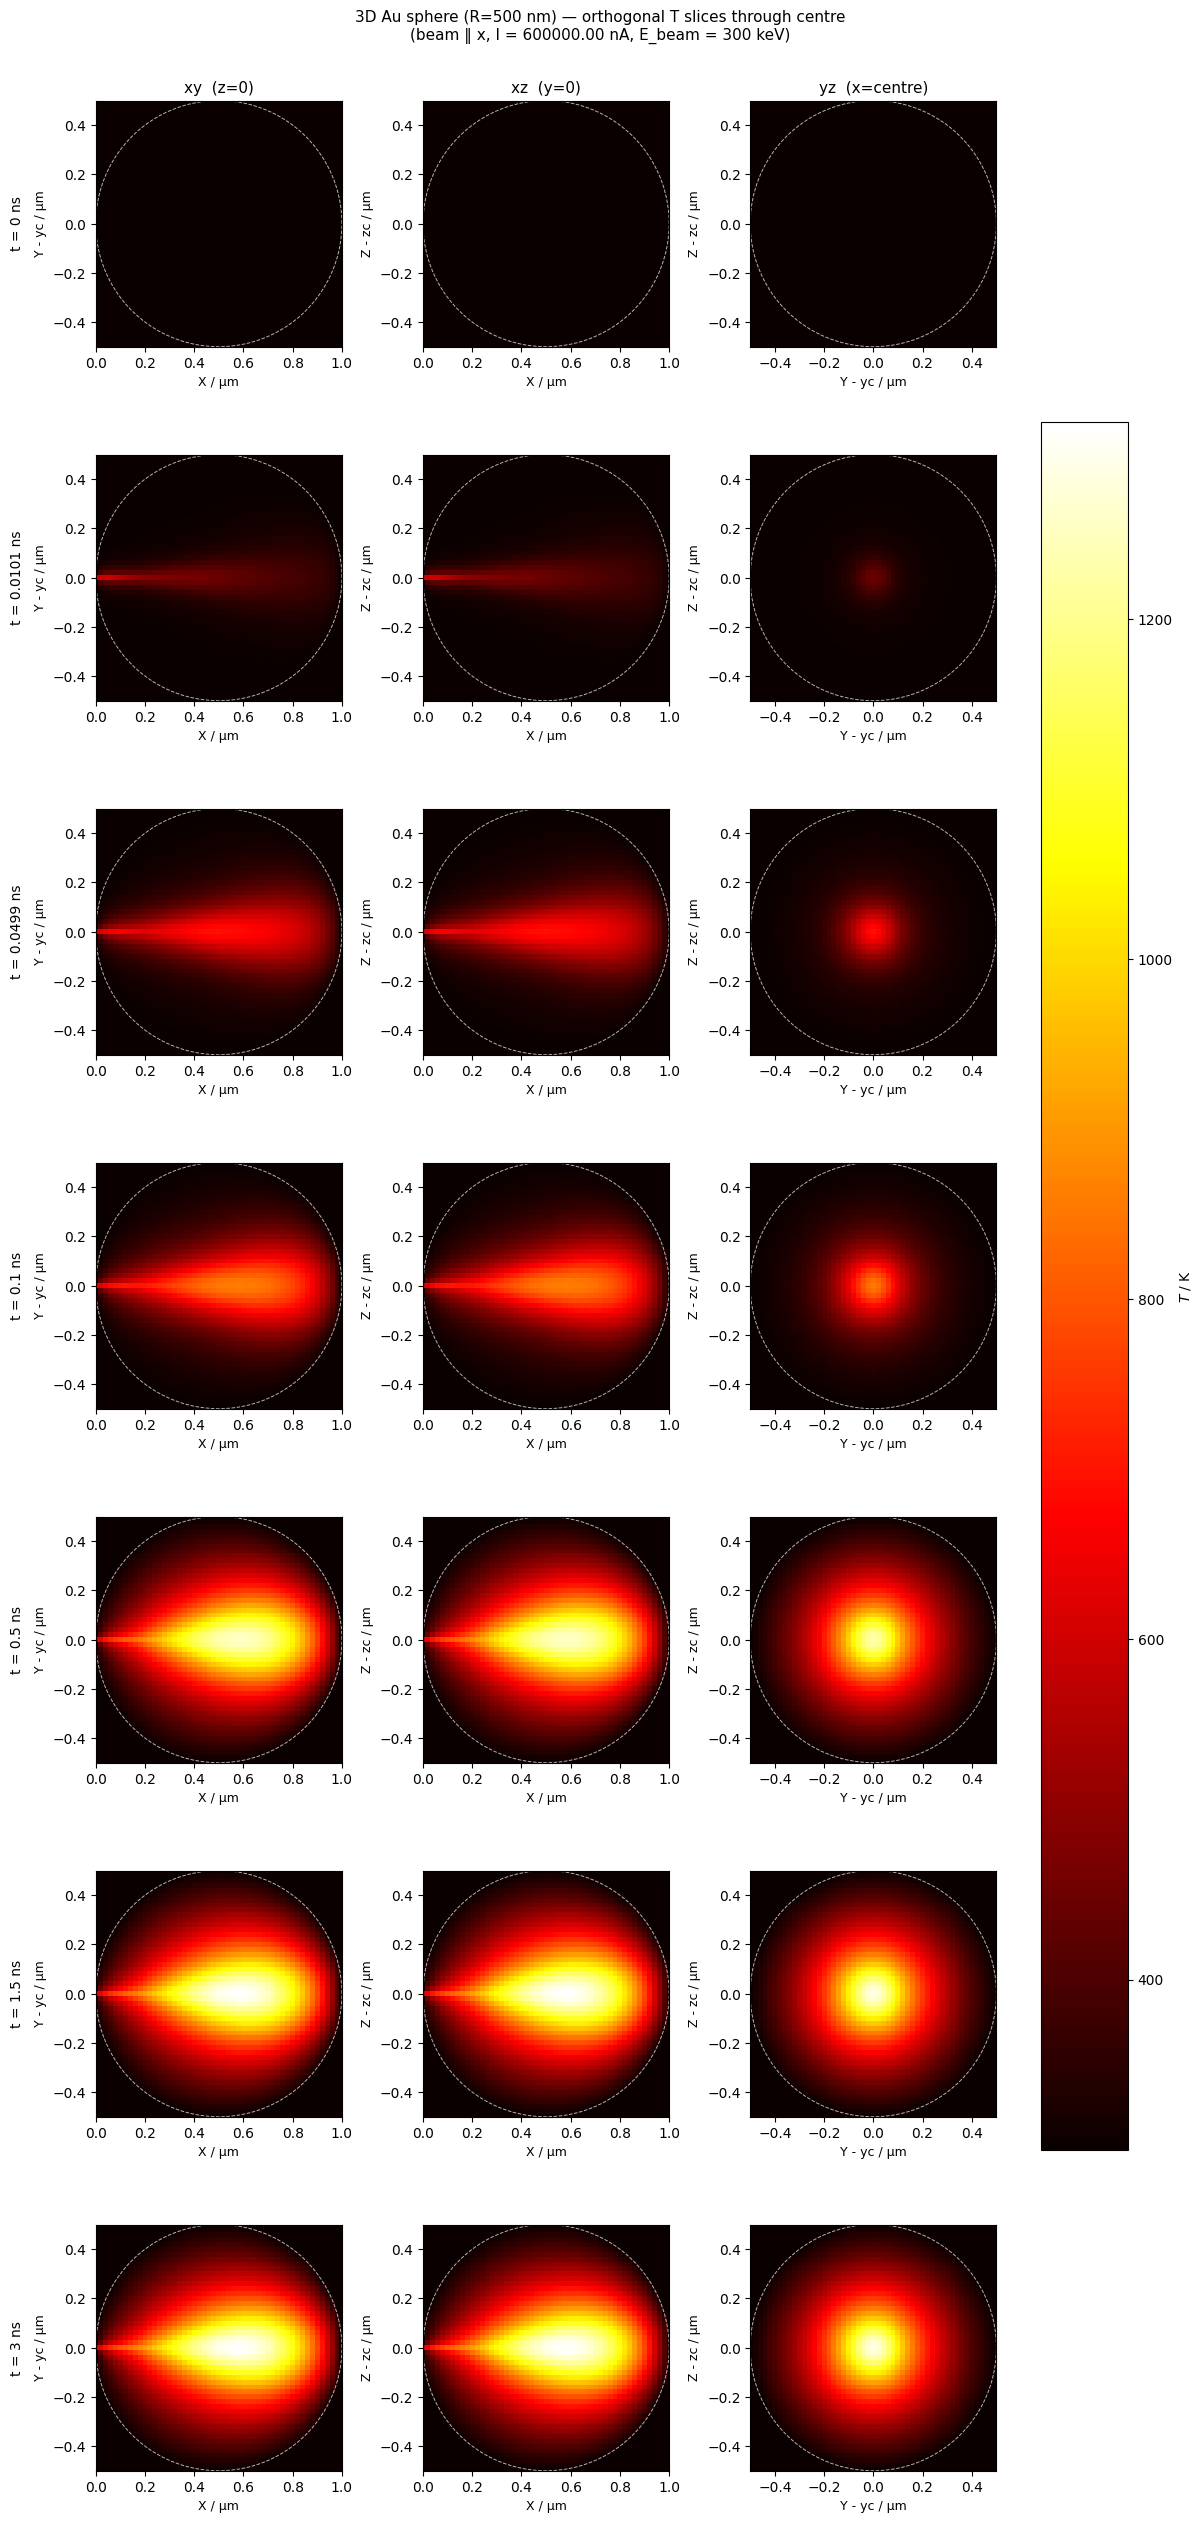

In [76]:
# Generated by GitHub Copilot
# ── Visualization 1: orthogonal slices through sphere centre, all snapshots ──
x_plt = x * 1e6          # µm, beam/depth coordinate from 0 to 1 µm
y_plt = (y - yc) * 1e6   # µm, transverse coordinate relative to sphere centre
z_plt = (z - zc) * 1e6

snap_items = sorted(snaps.items())
n_panels   = len(snap_items)

# Colour scale from T0 to global max across snapshots
T_vmax = max(T_sublimate_Au, max(arr[sphere_mask].max() for _, arr in snap_items))
T_vmin = T0

R_um = R_sphere * 1e6
x_center_um = xc * 1e6
theta_circ = np.linspace(0, 2*np.pi, 300)
circ_x     = x_center_um + R_um * np.cos(theta_circ)
circ_yz    = R_um * np.sin(theta_circ)

planes = [
    ('xy  (z=0)', x_plt, y_plt, lambda T_arr: T_arr[:, :, kc].T,
     'X / µm', 'Y - yc / µm', circ_x, circ_yz, (0.0, Lx*1e6), (-R_um, R_um)),
    ('xz  (y=0)', x_plt, z_plt, lambda T_arr: T_arr[:, jc, :].T,
     'X / µm', 'Z - zc / µm', circ_x, circ_yz, (0.0, Lx*1e6), (-R_um, R_um)),
    ('yz  (x=centre)', y_plt, z_plt, lambda T_arr: T_arr[ic, :, :].T,
     'Y - yc / µm', 'Z - zc / µm', R_um*np.cos(theta_circ), circ_yz, (-R_um, R_um), (-R_um, R_um)),
]

fig, axes = plt.subplots(
    n_panels, 3,
    figsize=(12.0, 3.6 * n_panels),
    squeeze=False,
    layout='constrained',
)

for i, (t_s, T_s) in enumerate(snap_items):
    for j, (title, a, b, slicer, xl, yl, circ_a, circ_b, xlim, ylim) in enumerate(planes):
        ax = axes[i, j]
        T_plot = slicer(T_s).astype(float)
        im = ax.pcolormesh(a, b, T_plot, shading='auto',
                           cmap='hot', vmin=T_vmin, vmax=T_vmax)
        ax.plot(circ_a, circ_b, 'w--', linewidth=0.7, alpha=0.7)
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_aspect('equal')
        ax.set_xlabel(xl, fontsize=9)
        ax.set_ylabel(yl, fontsize=9)
        if i == 0:
            ax.set_title(title, fontsize=11)
        if j == 0:
            ax.text(-0.32, 0.5, f't = {t_s*1e9:.3g} ns',
                    transform=ax.transAxes, rotation=90,
                    va='center', ha='center', fontsize=10)

fig.colorbar(im, ax=axes.ravel().tolist(), location='right',
             label=r'$T$ / K', shrink=0.7)
fig.suptitle(
    f'3D Au sphere (R={R_sphere*1e9:.0f} nm) — orthogonal T slices through centre\n'
    f'(beam ‖ x, I = {I_total*1e9:.2f} nA, E_beam = {E_beam_keV:.0f} keV)',
    fontsize=11)
plt.savefig('T3D_slices.png', dpi=150, bbox_inches='tight')
plt.show()


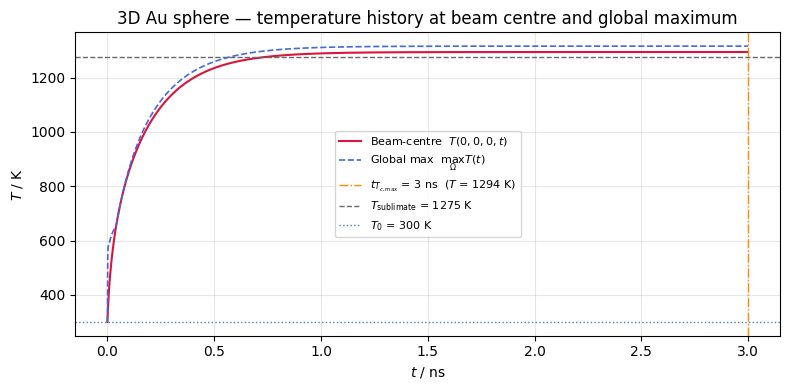

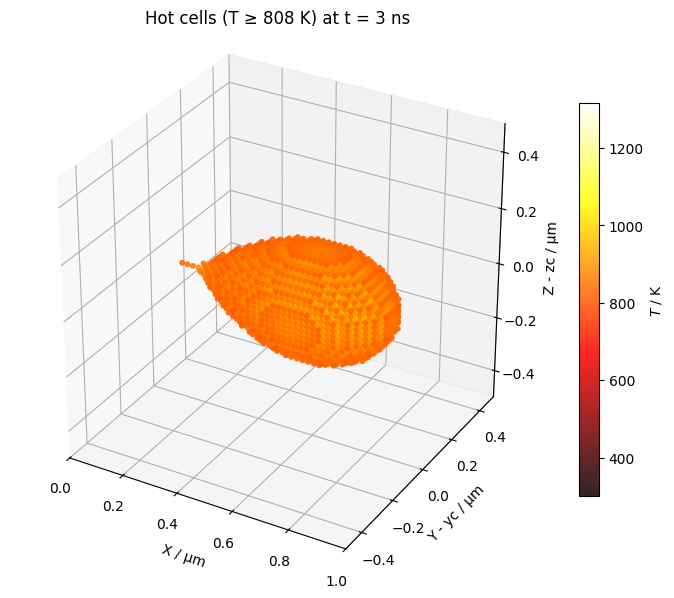

In [77]:
# Generated by GitHub Copilot
# ── Visualization 2: temperature histories (centre and global maximum) ───────
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(t_hist*1e9, Tc_hist,   color='crimson',   lw=1.5,
         label=r'Beam-centre  $T(0,0,0,t)$')
ax2.plot(t_hist*1e9, Tmax_hist, color='royalblue', lw=1.2, ls='--',
         label=r'Global max  $\max_{\Omega} T(t)$')
ax2.axvline(t_Tmax*1e9, color='darkorange', ls='-.', lw=1.0,
            label=f'$t_{{T_{{c,\\max}}}}$ = {t_Tmax*1e9:.2g} ns  '
                  f'($T$ = {T_max_centre:.0f} K)')
ax2.axhline(T_sublimate_Au, color='dimgray',  ls='--', lw=1.0,
            label=f'$T_\\mathrm{{sublimate}}$ = {T_sublimate_Au:.0f} K')
ax2.axhline(T0,            color='steelblue', ls=':',  lw=1.0,
            label=f'$T_0$ = {T0:.0f} K')
ax2.set_xlabel(r'$t$ / ns')
ax2.set_ylabel(r'$T$ / K')
ax2.set_title('3D Au sphere — temperature history at beam centre and global maximum')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.savefig('T3D_histories.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Visualization 3: 3D scatter of hot cells at the peak-temperature time ────
T_peak_field = snaps[min(snaps.keys(), key=lambda kt: abs(kt - t_Tmax))]
T_thresh     = T0 + 0.5 * (T_peak_field[sphere_mask].max() - T0)
hot          = (T_peak_field >= T_thresh) & sphere_mask
xs = X[hot] * 1e6
ys = (Y[hot] - yc) * 1e6
zs = (Z[hot] - zc) * 1e6
cs = T_peak_field[hot]

fig3 = plt.figure(figsize=(7, 6))
ax3  = fig3.add_subplot(111, projection='3d')
sc   = ax3.scatter(xs, ys, zs, c=cs, cmap='hot',
                   vmin=T_vmin, vmax=T_vmax, s=10, alpha=0.85)
ax3.set_xlabel('X / µm')
ax3.set_ylabel('Y - yc / µm')
ax3.set_zlabel('Z - zc / µm')
ax3.set_xlim(0.0, Lx*1e6)
ax3.set_ylim(-R_sphere*1e6, R_sphere*1e6)
ax3.set_zlim(-R_sphere*1e6, R_sphere*1e6)
ax3.set_box_aspect((1, 1, 1))
ax3.set_title(f'Hot cells (T ≥ {T_thresh:.0f} K) at t = {t_Tmax*1e9:.3g} ns')
fig3.colorbar(sc, ax=ax3, shrink=0.7, label=r'$T$ / K')
plt.tight_layout()
plt.savefig('T3D_hot_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


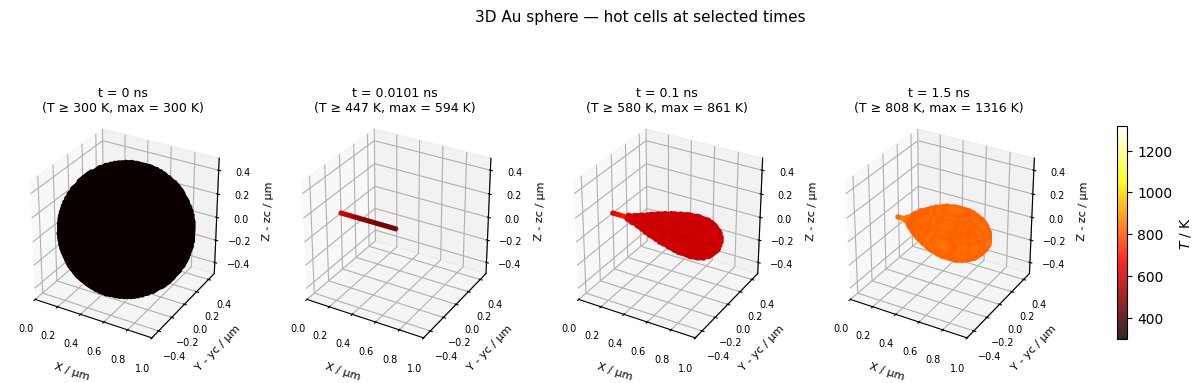

In [83]:
# ── Visualization 4: 3D hot-cell scatter at multiple snapshot times ──────────
target_times_ns = [0.0, 0.01, 0.1, 1.5]  # ns

def _nearest_snap(t_target_ns):
    """Return (t_actual_s, T_field) of snapshot closest to t_target_ns."""
    t_target_s = t_target_ns * 1e-9
    t_key = min(snaps.keys(), key=lambda kt: abs(kt - t_target_s))
    return t_key, snaps[t_key]

fig4, axes4 = plt.subplots(
    1, len(target_times_ns),
    figsize=(4.2 * len(target_times_ns), 4.6),
    subplot_kw={'projection': '3d'},
)
if len(target_times_ns) == 1:
    axes4 = [axes4]

last_sc = None
for ax, t_ns in zip(axes4, target_times_ns):
    t_actual, T_field = _nearest_snap(t_ns)
    T_in = T_field[sphere_mask]
    T_max_panel = T_in.max()
    if T_max_panel > T0 + 1e-6:
        T_thresh = T0 + 0.5 * (T_max_panel - T0)
    else:
        T_thresh = T0  # show all in-sphere cells when field is flat
    hot = (T_field >= T_thresh) & sphere_mask

    xs = X[hot] * 1e6
    ys = (Y[hot] - yc) * 1e6
    zs = (Z[hot] - zc) * 1e6
    cs = T_field[hot]

    last_sc = ax.scatter(xs, ys, zs, c=cs, cmap='hot',
                         vmin=T_vmin, vmax=T_vmax, s=8, alpha=0.85)
    ax.set_xlabel('X / µm', fontsize=8)
    ax.set_ylabel('Y - yc / µm', fontsize=8)
    ax.set_zlabel('Z - zc / µm', fontsize=8)
    ax.set_title(f't = {t_actual*1e9:.3g} ns\n'
                 f'(T ≥ {T_thresh:.0f} K, max = {T_max_panel:.0f} K)',
                 fontsize=9)
    lim = R_sphere * 1e6
    ax.set_xlim(0.0, Lx*1e6)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)
    ax.set_box_aspect((1, 1, 1))
    ax.tick_params(labelsize=7)

fig4.colorbar(last_sc, ax=axes4, shrink=0.6, label=r'$T$ / K', pad=0.05)
fig4.suptitle('3D Au sphere — hot cells at selected times', fontsize=11)
plt.savefig('T3D_hot_scatter_multi.png', dpi=150, bbox_inches='tight')
plt.show()


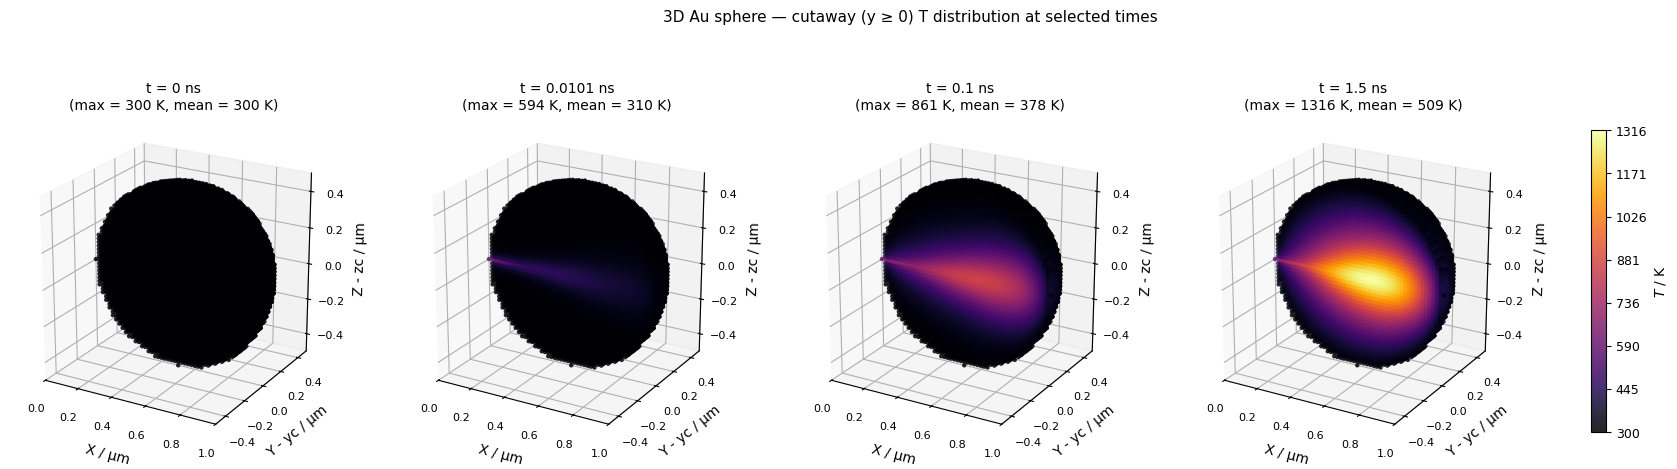

In [84]:
# ── Visualization 5: 3D scatter of the FULL sphere (cutaway) at multiple times
# Cutaway: keep only cells with y >= y_c so the interior of the sphere is
# visible. Colour every kept in-sphere cell by T using a high-contrast cmap.
from matplotlib.colors import Normalize

target_times_ns_full = [0.0, 0.01, 0.1, 1.5]  # ns

# Cutaway mask (front half removed: show y >= yc)
cut_mask  = sphere_mask & (Y >= yc)
xs_cut = X[cut_mask] * 1e6
ys_cut = (Y[cut_mask] - yc) * 1e6
zs_cut = (Z[cut_mask] - zc) * 1e6

# Linear normalisation so the colour bar is evenly distributed in T.
T_vmax_full = max(T_vmax, max(snaps[k][sphere_mask].max() for k in snaps))
norm = Normalize(vmin=T0, vmax=T_vmax_full)
cmap = plt.get_cmap('inferno')

fig5, axes5 = plt.subplots(
    1, len(target_times_ns_full),
    figsize=(6.0 * len(target_times_ns_full), 5.6),
    subplot_kw={'projection': '3d'},
)
if len(target_times_ns_full) == 1:
    axes5 = [axes5]

last_sc5 = None
for ax, t_ns in zip(axes5, target_times_ns_full):
    t_actual, T_field = _nearest_snap(t_ns)
    cs = T_field[cut_mask]
    last_sc5 = ax.scatter(xs_cut, ys_cut, zs_cut, c=cs, cmap=cmap,
                          norm=norm, s=10, alpha=0.85,
                          edgecolors='none', depthshade=False)
    ax.set_xlabel('X / µm', fontsize=10)
    ax.set_ylabel('Y - yc / µm', fontsize=10)
    ax.set_zlabel('Z - zc / µm', fontsize=10)
    ax.set_title(f't = {t_actual*1e9:.3g} ns\n'
                 f'(max = {T_field[sphere_mask].max():.0f} K, '
                 f'mean = {T_field[sphere_mask].mean():.0f} K)',
                 fontsize=10)
    lim = R_sphere * 1e6
    ax.set_xlim(0.0, Lx*1e6)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=22, azim=-60)
    ax.tick_params(labelsize=8)

cbar = fig5.colorbar(last_sc5, ax=axes5, shrink=0.7, pad=0.04,
                     label=r'$T$ / K')
# Evenly spaced ticks in physical T from T0 to T_vmax_full
n_ticks = 8
tick_vals = np.linspace(T0, T_vmax_full, n_ticks)
cbar.set_ticks(tick_vals)
cbar.set_ticklabels([f'{v:.0f}' for v in tick_vals])
cbar.ax.tick_params(labelsize=9)

fig5.suptitle('3D Au sphere — cutaway (y ≥ 0) T distribution at selected times',
              fontsize=11)
plt.savefig('T3D_full_scatter_multi.png', dpi=200, bbox_inches='tight')
plt.show()


In [80]:
# Generated by GitHub Copilot
# ── CSV exports: per-snapshot 3D fields and time histories ───────────────────
out_dir = 'T3D_csv'
os.makedirs(out_dir, exist_ok=True)

# (1) One CSV per snapshot: x[µm], y[µm], z[µm], T[K], for in-sphere cells only
saved = []
xs_um = (X - xc) * 1e6
ys_um = (Y - yc) * 1e6
zs_um = (Z - zc) * 1e6
flat_mask = sphere_mask.ravel()
for t_s, T_s in sorted(snaps.items()):
    fname = os.path.join(
        out_dir, f'T3D_snapshot_t_{t_s*1e9:08.4f}ns.csv'
    )
    arr = np.column_stack([
        xs_um.ravel()[flat_mask],
        ys_um.ravel()[flat_mask],
        zs_um.ravel()[flat_mask],
        T_s.ravel()[flat_mask],
    ])
    np.savetxt(fname, arr,
               header='x_um,y_um,z_um,T_K', delimiter=',', comments='')
    saved.append(fname)

# (2) Time-history CSV
hist_path = os.path.join(out_dir, 'T3D_histories.csv')
np.savetxt(hist_path,
           np.column_stack([t_hist*1e9, Tc_hist, Tmax_hist]),
           header='t_ns,T_centre_K,T_max_K', delimiter=',', comments='')

print(f'  Saved {len(saved)} snapshot CSVs in ./{out_dir}/')
for f in saved:
    print(f'    - {f}')
print(f'  Saved time histories      : {hist_path}')
print(f'  Saved figures             : T3D_slices.png, T3D_histories.png, T3D_hot_scatter.png')


  Saved 7 snapshot CSVs in ./T3D_csv/
    - T3D_csv\T3D_snapshot_t_000.0000ns.csv
    - T3D_csv\T3D_snapshot_t_000.0101ns.csv
    - T3D_csv\T3D_snapshot_t_000.0499ns.csv
    - T3D_csv\T3D_snapshot_t_000.1000ns.csv
    - T3D_csv\T3D_snapshot_t_000.5000ns.csv
    - T3D_csv\T3D_snapshot_t_001.5000ns.csv
    - T3D_csv\T3D_snapshot_t_003.0000ns.csv
  Saved time histories      : T3D_csv\T3D_histories.csv
  Saved figures             : T3D_slices.png, T3D_histories.png, T3D_hot_scatter.png
